In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('spaceship-titanic')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/spaceship-titanic


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

In [4]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [8]:
print(df.shape)
print(test.shape)

(8693, 14)
(4277, 13)


In [9]:
df['HomePlanet'].value_counts()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

In [10]:
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
test['HomePlanet'] = test['HomePlanet'].fillna(test['HomePlanet'].mode()[0])

In [11]:
df['CryoSleep'].value_counts()

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

In [12]:
df['CryoSleep'].isnull().sum()

np.int64(217)

In [13]:
spending_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for dataset in [df,test]:
    dataset['TotalSpending'] = dataset[spending_cols].fillna(0).sum(axis = 1)

for dataset in [df,test]:
    dataset.loc[(dataset['CryoSleep'].isnull()) & (dataset['TotalSpending'] > 0), 'CryoSleep'] = False

for dataset in [df,test]:
    dataset['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
    dataset['CryoSleep'] = dataset['CryoSleep'].astype(bool)

df['CryoSleep'].isnull().sum()

np.int64(0)

In [14]:
df.Cabin.value_counts()

Cabin
G/734/S     8
B/11/S      7
F/1411/P    7
B/82/S      7
G/981/S     7
           ..
G/543/S     1
B/106/P     1
G/542/S     1
F/700/P     1
G/559/P     1
Name: count, Length: 6560, dtype: int64

In [15]:

for dataset in [df,test]:
    dataset['Group'] = dataset['PassengerId'].str.split('-').str[0]

cabin_map = df.dropna(subset=['Cabin']).set_index('Group')['Cabin'].to_dict()
cabin_map.update(test.dropna(subset=['Cabin']).set_index('Group')['Cabin'].to_dict())

for dataset in [df,test]:
    dataset['Cabin'] = dataset['Cabin'].fillna(dataset['Group'].map(cabin_map))

    dataset['Cabin'] = dataset['Cabin'].fillna('Unknown/-1/Unknown')

    dataset[['Deck','Num', 'Side']] = dataset['Cabin'].str.split('/',expand = True)
    dataset['Num'] = dataset['Num'].astype(int)
    dataset.drop('Cabin',axis=1,inplace = True)

print(df[['Deck','Num','Side']].head())
print("\nMissing values in Deck: ",df.Deck.isnull().sum())

  Deck  Num Side
0    B    0    P
1    F    0    S
2    A    0    S
3    A    0    S
4    F    1    S

Missing values in Deck:  0


In [16]:
df.Destination.value_counts()

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

In [17]:
dest_map = {'TRAPPIST-1e':0 , '55 Cancri e':1 , 'PSO J318.5-22':2}

for dataset in [df,test]:
    dataset['Destination'] = dataset['Destination'].fillna(df['Destination'].mode()[0])
    dataset['Destination'] = dataset['Destination'].replace(dest_map).astype(int)

df['Destination'].value_counts()

Destination
0    6097
1    1800
2     796
Name: count, dtype: int64

In [18]:
for dataset in [df,test]:
    dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
    dataset['VIP'] = dataset['VIP'].fillna(dataset['VIP'].mode()[0])
    dataset['VIP'] = dataset['VIP'].astype(int)
    

In [19]:
print(df[spending_cols].isnull().sum())

RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
dtype: int64


In [20]:
for dataset in [df,test]:
    dataset[spending_cols] = dataset[spending_cols].fillna(0.0)
    dataset['TotalSpending'] = dataset[spending_cols].sum(axis=1)

print(df[spending_cols].isnull().sum())

RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


In [21]:
df.drop('Name',axis = 1,inplace = True)
test.drop('Name',axis = 1,inplace = True)

In [22]:
df.isnull().sum()

PassengerId      0
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Transported      0
TotalSpending    0
Group            0
Deck             0
Num              0
Side             0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    8693 non-null   object 
 1   HomePlanet     8693 non-null   object 
 2   CryoSleep      8693 non-null   bool   
 3   Destination    8693 non-null   int64  
 4   Age            8693 non-null   float64
 5   VIP            8693 non-null   int64  
 6   RoomService    8693 non-null   float64
 7   FoodCourt      8693 non-null   float64
 8   ShoppingMall   8693 non-null   float64
 9   Spa            8693 non-null   float64
 10  VRDeck         8693 non-null   float64
 11  Transported    8693 non-null   bool   
 12  TotalSpending  8693 non-null   float64
 13  Group          8693 non-null   object 
 14  Deck           8693 non-null   object 
 15  Num            8693 non-null   int64  
 16  Side           8693 non-null   object 
dtypes: bool(2), float64(7), int64(3), object(5)
memory u

In [24]:
for dataset in [df,test]:
    dataset['HomePlanet'] = dataset['HomePlanet'].fillna('Earth').replace({'Earth': 0, 'Europa': 1, 'Mars': 2})
    dataset['CryoSleep'] = dataset['CryoSleep'].fillna(False).astype(int)

    deck_list = ['A','B','C','D','E','F','G','T','Unknown']
    deck_map = {deck:i for i,deck in enumerate(deck_list)}
    dataset['Deck'] = dataset['Deck'].fillna('Unknown').replace(deck_map)

    Side_map = {'S':0,'P':1,'Unknown':2}
    dataset['Side'] = dataset['Side'].fillna('Unknown').replace(Side_map)

df['Transported'] = df['Transported'].astype(int)
    

In [25]:
test_ids = test['PassengerId']

dropping_cols = ['PassengerId','Group']

df_final = df.drop(dropping_cols,axis = 1)
test_final = test.drop(dropping_cols,axis = 1)

In [26]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     8693 non-null   int64  
 1   CryoSleep      8693 non-null   int64  
 2   Destination    8693 non-null   int64  
 3   Age            8693 non-null   float64
 4   VIP            8693 non-null   int64  
 5   RoomService    8693 non-null   float64
 6   FoodCourt      8693 non-null   float64
 7   ShoppingMall   8693 non-null   float64
 8   Spa            8693 non-null   float64
 9   VRDeck         8693 non-null   float64
 10  Transported    8693 non-null   int64  
 11  TotalSpending  8693 non-null   float64
 12  Deck           8693 non-null   int64  
 13  Num            8693 non-null   int64  
 14  Side           8693 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 1018.8 KB


In [27]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     4277 non-null   int64  
 1   CryoSleep      4277 non-null   int64  
 2   Destination    4277 non-null   int64  
 3   Age            4277 non-null   float64
 4   VIP            4277 non-null   int64  
 5   RoomService    4277 non-null   float64
 6   FoodCourt      4277 non-null   float64
 7   ShoppingMall   4277 non-null   float64
 8   Spa            4277 non-null   float64
 9   VRDeck         4277 non-null   float64
 10  TotalSpending  4277 non-null   float64
 11  Deck           4277 non-null   int64  
 12  Num            4277 non-null   int64  
 13  Side           4277 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 467.9 KB


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

X = df_final.drop('Transported',axis=1)
y = df_final['Transported']

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=2)

model = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 2)

model.fit(X_train,y_train)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance',ascending = False)

y_pred = model.predict(X_val)
print("Accuracy Score: ",accuracy_score(y_val,y_pred))

Accuracy Score:  0.8056354226566993


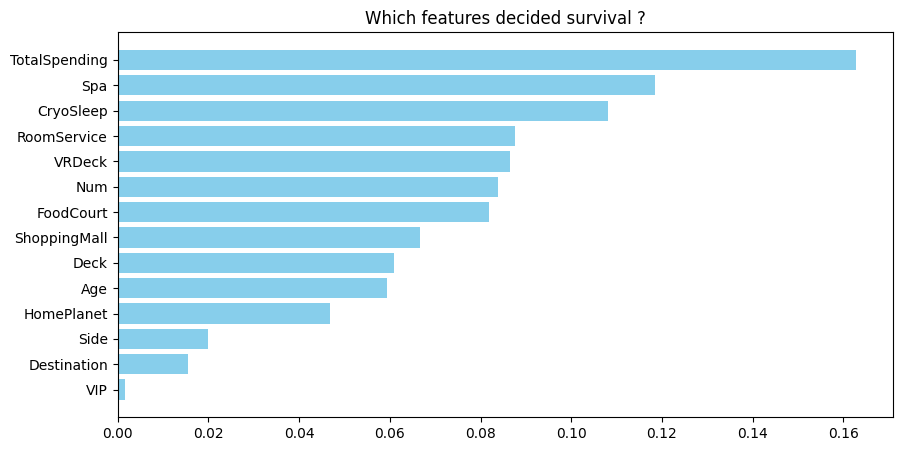

In [29]:
plt.figure(figsize=(10,5))
plt.barh(feature_importance_df['Feature'],feature_importance_df['Importance'],color='skyblue')
plt.gca().invert_yaxis()
plt.title('Which features decided survival ?')
plt.show()

In [30]:
predictions = model.predict(test_final)
predictions_bool = predictions.astype(bool)

submission = pd.DataFrame({
    'PassengerId' : test_ids,
    'Transported' : predictions_bool
})

submission.to_csv("submission.csv",index = False)
print("Submission file saved successfully!")

Submission file saved successfully!
